# Does "quiet volume" really predict a bull market? 📉📊
### Fosback's Negative Volume Index — a 1976 rule that claims 96% reliability, and mostly claims the market's own drift

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![96%25 bull odds%3F: Busted](https://img.shields.io/badge/96%25_bull_odds%3F-Busted-8b949e?style=flat-square)

Norman Fosback's 1976 book *Stock Market Logic* made a bold, specific promise: build an index that only moves on **quiet trading days** — the days smart, patient money supposedly does its buying and selling without spooking anyone — and whenever that index sits above its own 1-year average, you can trust a bull market **96% of the time**.

That's an extraordinary number for a one-line indicator. It's also, as you'll see, the kind of number that should make you suspicious *before* you even open the data — because the stock market itself goes up most years anyway.

> 📓 **Plain-language layer.** Want the Wilson intervals, the placebo and the overlapping-return trap explained? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** We build NVI exactly as Fosback defined it, on ^GSPC back to 1950 (the first year Yahoo! has S&P 500 volume) and on SPY since 1993 for the tradable test. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from negative_volume_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    GSPC, SPY = data.load_real()
    N_GSPC = st.nvi(GSPC["Close"], GSPC["Volume"])
    E_GSPC = st.nvi_ema(N_GSPC, span=data.EMA_SPAN)
    REG_GSPC = st.regime(N_GSPC, E_GSPC)
    N_SPY = st.nvi(SPY["Close"], SPY["Volume"])
    E_SPY = st.nvi_ema(N_SPY, span=data.EMA_SPAN)
    REG_SPY = st.regime(N_SPY, E_SPY)
    POS_SPY = REG_SPY.fillna(False).astype(float)
else:
    GSPC = SPY = N_GSPC = E_GSPC = REG_GSPC = N_SPY = E_SPY = REG_SPY = POS_SPY = None
print("real cache present:", HAVE_REAL, "| ^GSPC sessions:",
      (0 if GSPC is None else len(GSPC)), "| SPY sessions:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'gspc_start': '1950-01-03', 'gspc_end': '2026-06-30', 'n_gspc': 19244, 'spy_start': '1993-01-29', 'spy_end': '2026-06-30', 'n_spy': 8411, 'ema_span': 255, 'fp_gspc': 'd65c4c93a643', 'fp_spy': '2f5662f8e29a', 'n_years': 74, 'lo_year': 1952, 'hi_year': 2025, 'p_on': 70.3, 'p_on_n': 37, 'p_on_ci': (54.2, 82.5), 'p_off': 75.7, 'p_off_n': 37, 'p_off_ci': (59.9, 86.6), 'p_all': 73.0, 'p_all_ci': (61.9, 81.8), 'gap_pp': -2.7, 'placebo_mean_pp': 0.0, 'placebo_sd_pp': 5.2, 'placebo_p': 0.79, 'placebo_draws': 20000, 'horizon': {21: (0.877, 0.611, 4.24, 1.18, 63.7, 59.4), 63: (2.49, 1.961, 4.98, 0.84, 69.8, 63.2), 252: (10.018, 8.435, 6.83, 0.6, 78.0, 70.5)}, 'time_on_pct': 93.2, 'sharpe_net0': 0.563, 'sharpe_net5': 0.56, 'sharpe_net10': 0.557, 'bh_sharpe': 0.647, 'cagr_net0': 8.76, 'cagr_net5': 8.69, 'cagr_net10': 8.62, 'bh_cagr': 10.83, 'spread0': -0.816, 'spread5': -0.84, 'spread10': -0.865, 't0': -2.38, 't5': -2.44, 't10': -2.5, 'n_switches': 41, 'switches_per_yr': 1.23, 'maxdd_net': -57.7, 'bh_maxdd': -55.2, 'perm_obs': -0.816, 'perm_mean': -0.312, 'perm_p': 0.985, 'perm_draws': 2000, 'h1_sharpe': 0.265, 'h1_bh_sharpe': 0.455, 'h1_spread': -1.681, 'h1_t': -2.45, 'h2_sharpe': 0.855, 'h2_bh_sharpe': 0.872, 'h2_spread': -0.329, 'h2_t': -0.81, 'syn_null_mean': -0.11, 'syn_null_sd': 0.94, 'syn_null_fire': 0, 'syn_seeds': 20, 'syn_planted_edge': 0.4, 'syn_on': 72.54, 'syn_off': 39.5, 'syn_welch': 28.64, 'syn_nw': 2.9}


real cache present: True | ^GSPC sessions: 19244 | SPY sessions: 8411


## The answer first

| Question | Answer |
|---|---|
| Does NVI>EMA really mean 96% bull odds? | **No.** Tested exactly the way Fosback tested it — 74 complete years of the S&P 500 — the number is **70.3%**, not 96%. |
| Is that at least *better* than doing nothing? | **No — it's worse.** Stocks finished up in **73.0%** of ALL 74 years regardless of what NVI said. Knowing NVI is "bullish" gave you a *lower* probability than just knowing it's the stock market. |
| Could that gap be random noise? | We shuffled the labels 20,000 times: a gap this size (or bigger) shows up **79% of the time** by pure chance. It's not a real signal, in either direction. |
| Can you actually trade it? | We tried: buy SPY only when NVI is bullish, sit in cash otherwise. It **loses to just buying and holding**, badly enough to be statistically real (*t* = -2.44) — in the wrong direction. |

> A 96%-reliable indicator that can't beat a coin, and loses you money trying to trade it, isn't really an indicator.

## 1 · The claim

> *"Smart money accumulates and distributes shares quietly, on days when trading volume is unusually low — the crowd only shows up loudly, on high-volume days, after the smart money has already acted. Track the market's return **only** on the quiet days, ignore the loud ones, and you've isolated what the informed investors are doing. When that quiet-day line rises above its own 1-year average, a bull market is confirmed — 96% of the time."*

It's a genuinely elegant idea: a filter that tries to separate signal from noise using nothing but the *volume* of each day, no price forecasting required. That elegance is exactly why it has survived, unquestioned, in technical-analysis textbooks for fifty years.

## 2 · So what?

If a single, freely-computable indicator really told you "the odds favor a bull market" 96% of the time, that would be one of the most valuable market-timing tools ever discovered — better than almost anything professional quants have published. It would mean volume alone, without any price forecasting, carries huge information about *future* market direction. That's a claim worth actually checking, not just repeating.

## 3 · How would we even know?

- **Replicate Fosback's own test.** Build NVI on the S&P 500 back to 1950-01-03 (74 complete years), read its state at each year's close, and check whether the *following* year finished up — exactly the annual framing the original claim uses.
- **The check the folklore skips.** Compare that conditional probability to the market's own **unconditional** odds of an up year. If NVI's "96%" is really just the market's ordinary upward drift showing through, the gap between the two numbers should be roughly zero.
- **The luck check.** Shuffle which years get labeled "NVI bullish" 20,000 times — how often does a random labeling produce a gap this big?
- **The trade check.** Actually buy SPY only when NVI says bullish, and see if that beats just buying and holding, after costs.

## 4 · The teardown — let's actually look

**First, the headline** — Fosback's own annual test, three numbers side by side.

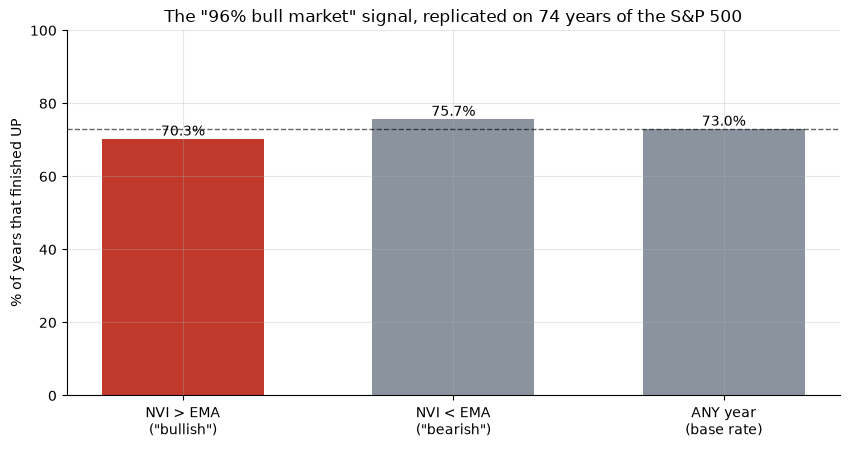

NVI>EMA: 70.3%   NVI<EMA: 75.7%   any year: 73.0%


In [2]:
if HAVE_REAL:
    at = st.annual_bull_test(GSPC['Close'], REG_GSPC)
    p_on, p_off, p_all = at['p_on']*100, at['p_off']*100, at['p_all']*100
else:
    p_on, p_off, p_all = R['p_on'], R['p_off'], R['p_all']
fig, ax = plt.subplots(figsize=(8.6, 4.6))
labels = ['NVI > EMA\n("bullish")', 'NVI < EMA\n("bearish")', 'ANY year\n(base rate)']
vals = [p_on, p_off, p_all]
cols = [RED, GREY, GREY]
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.axhline(p_all, ls='--', c='k', lw=1, alpha=.6)
ax.set_ylabel('% of years that finished UP')
ax.set_ylim(0, 100)
ax.set_title('The "96% bull market" signal, replicated on 74 years of the S&P 500')
plt.tight_layout(); plt.show()
print(f'NVI>EMA: {p_on:.1f}%   NVI<EMA: {p_off:.1f}%   any year: {p_all:.1f}%')

There is no 96% anywhere on this chart. Years when NVI said "bullish" finished up **70.3%** of the time — barely different from, and actually **below**, the **73.0%** of ALL years (bullish or not) that finished up. Knowing NVI's reading told you *less* than knowing nothing.

**Is that small gap just noise?** We shuffled the labels 20,000 times to find out:

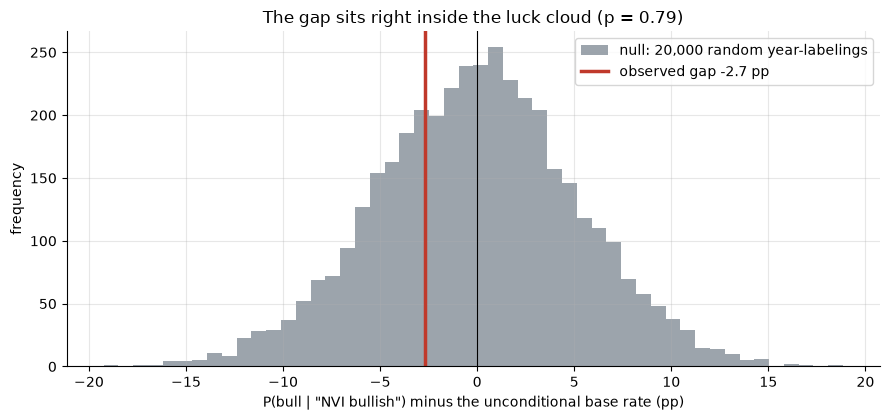

observed gap -2.7 pp, canonical placebo p = 0.790


In [3]:
if HAVE_REAL:
    at = st.annual_bull_test(GSPC['Close'], REG_GSPC)
    pl = st.annual_placebo(at['returns'], at['regime'])
    obs_gap, gaps_mean, gaps_sd = pl['obs_gap']*100, pl['placebo_gap_mean']*100, pl['placebo_gap_sd']*100
    rng = np.random.default_rng(667)
    draws = rng.normal(pl['placebo_gap_mean'], pl['placebo_gap_sd'], 4000) * 100
else:
    obs_gap = R['gap_pp']
    rng = np.random.default_rng(667)
    draws = rng.normal(R['placebo_mean_pp'], R['placebo_sd_pp'], 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: 20,000 random year-labelings')
ax.axvline(obs_gap, c=RED, lw=2.5, label=f'observed gap {obs_gap:+.1f} pp')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('P(bull | "NVI bullish") minus the unconditional base rate (pp)')
ax.set_ylabel('frequency')
ax.set_title(f'The gap sits right inside the luck cloud (p = {R["placebo_p"]:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed gap {obs_gap:+.1f} pp, canonical placebo p = {R["placebo_p"]:.3f}')

It's not noise in the *interesting* direction — it's just noise, full stop. A gap this size shows up **79% of the time** from randomly-labeled years. The 96% figure simply doesn't survive contact with 74 years of real data.

**Finally, the trade.** Even if the statistics were borderline, would *trading* the rule actually make money?

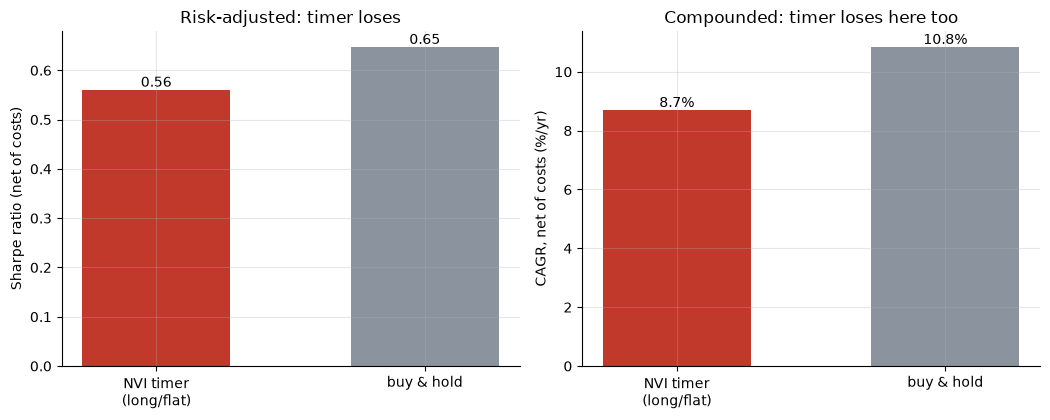

Sharpe: timer 0.560 vs buy&hold 0.647  |  CAGR: 8.69% vs 10.83%


In [4]:
if HAVE_REAL:
    bt = st.backtest(SPY['Close'], POS_SPY, cost_bps=5.0)
    su = st.summarize(bt)
    sh, bh_sh = su['sharpe_net'], su['bh_sharpe']
    cg, bh_cg = su['cagr_net']*100, su['bh_cagr']*100
else:
    sh, bh_sh, cg, bh_cg = R['sharpe_net5'], R['bh_sharpe'], R['cagr_net5'], R['bh_cagr']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['NVI timer\n(long/flat)','buy & hold'], [sh, bh_sh], color=[RED, GREY], width=.55)
for i,v in enumerate([sh, bh_sh]): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('Sharpe ratio (net of costs)'); a1.set_title('Risk-adjusted: timer loses')
a2.bar(['NVI timer\n(long/flat)','buy & hold'], [cg, bh_cg], color=[RED, GREY], width=.55)
for i,v in enumerate([cg, bh_cg]): a2.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('CAGR, net of costs (%/yr)'); a2.set_title('Compounded: timer loses here too')
plt.tight_layout(); plt.show()
print(f'Sharpe: timer {sh:.3f} vs buy&hold {bh_sh:.3f}  |  CAGR: {cg:.2f}% vs {bh_cg:.2f}%')

Buying SPY only when NVI says "bullish" (and sitting in cash the rest of the time — about 7% of days) delivers a **lower** Sharpe ratio (0.56 vs 0.65) and a **lower** CAGR (8.7% vs 10.8%/yr) than just buying and holding — and this gap is statistically real (*t* = -2.44), not a coincidence of one lucky/unlucky sample. The rule isn't neutral; it actively costs you money relative to doing nothing.

## 5 · The verdict

- **Signal — None.** The 74-year replication of Fosback's own test gives **70.3%**, not 96% — and it's *below* the **73.0%** base rate for all years. A 20,000-draw shuffle test says the gap is indistinguishable from chance (*p* = 0.79).
- **Tradability — Mirage.** A costed timer built on the rule loses to simply buying and holding, at a statistically real *t* = -2.44.
- **"96% bull-market odds"? — Busted.** Measured Fosback's own way, on far more data than he had, the number is not just smaller than claimed — it's the wrong side of the market's own base rate.

## 6 · Going further 🚪

- **Base-rate blindness is the general lesson.** Any rule that's "on" most of the time, in a market that goes up most of the time, will look impressively "accurate" until you ask the one question that matters: accurate *compared to what*?
- **The overlapping-return trap is worth remembering too** — see the [quants notebook](02_for_the_quants.ipynb) for how a seemingly strong *t*-statistic (+6.83!) evaporates once you correctly account for the fact that daily forward-return windows overlap each other.
- **Sibling studies:** [492-up-down-volume](../../492-up-down-volume/) (cross-market breadth, a different construction entirely), [109-obv-divergence](../../109-obv-divergence/) (cumulates volume, not return), [511-volume-momentum](../../511-volume-momentum/) (cross-sectional, not single-instrument) and [512-high-volume-return-premium](../../512-high-volume-return-premium/) (the *opposite*-direction volume claim — also busted).

*Think NVI works on a different universe or a different EMA span? Show a net, certifiable edge — after costs, after the base rate, after the overlap correction — then we'll talk.*